In [ ]:
import os
import glob
import pickle
import yaml

import numpy as np
import geopandas as gpd

import rasterio
from rasterio.plot import show

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import matplotlib.colors as mplc

from utils.data_preprocessing import clean_region_name, landcover_stats_df
from utils.legends import legend_dict_esa_worldcover2021


with open("configs/config.yaml", "r") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

In [2]:
region_name = clean_region_name(config["study_region_name"])

# Get path to this file and then also path to data
dirname = os.getcwd()
data_path = os.path.join(dirname, "data", region_name)
data_path2 = os.path.join(dirname, "data", region_name, "derived_from_DEM")
OSM_data_path = os.path.join(data_path, "OSM_Infrastructure")

maps_dir = os.path.join(data_path, "maps")
os.makedirs(maps_dir, exist_ok=True)

# Load the CRS
# geo CRS
with open(os.path.join(data_path, region_name + "_global_CRS.pkl"), "rb") as file:
    global_crs_obj = pickle.load(file)
# projected CRS
with open(os.path.join(data_path, region_name + "_local_CRS.pkl"), "rb") as file:
    local_crs_obj = pickle.load(file)

print(f"geo CRS: {global_crs_obj}; projected CRS: {local_crs_obj}")

# Extract tag for filename, e.g., 'EPSG3035' or 'ESRI102003'
auth = global_crs_obj.to_authority()
global_crs_tag = "".join(auth) if auth else global_crs_obj.to_string().replace(":", "_")
auth = local_crs_obj.to_authority()
local_crs_tag = "".join(auth) if auth else local_crs_obj.to_string().replace(":", "_")

regionPath = os.path.join(data_path, f"{region_name}_{local_crs_tag}.geojson")
region_boundary = gpd.read_file(regionPath)

geo CRS: EPSG:4326; projected CRS: EPSG:32632


In [ ]:
import leafmap
import geopandas as gpd

# Select scenario and technology for available land raster (set values here)
scenario = "test1"  # e.g., 'test1', 'test2', 'test3'
technology = "solar"  # e.g., 'solar', 'wind'

m = leafmap.Map()

# GeoTIFF - localtileserver handles it efficiently under the hood
landcover_raster_path = os.path.join(
    data_path, f"landcover_openeo_{region_name}_{local_crs_tag}.tif"
)
solar_raster_path = os.path.join(data_path, f"solar_{region_name}_{local_crs_tag}.tif")
wind_raster_path = os.path.join(data_path, f"wind_{region_name}_{local_crs_tag}.tif")

# Unified legend and color dict for all map elements
legend_dict = {
    "Landcover": "terrain",
    "Solar Raster": "OrRd",
    "Wind Raster": "GnBu",
    "Available Land": "PiYG",
    "Roads": "#8e6f07",
    "Airports": "#fa0000",
    "Waterbodies": "#2211e1",
    "Military": "#de29e7",
    "Railways": "#a65d1e",
    "Transmission Lines": "#f0a500",
    "Substations": "#00a99d",
    "Protected Areas": "#228B22",
    "Region Boundary": "#000000",
}

# Set nodata transparency for solar raster
with rasterio.open(solar_raster_path) as src:
    nodata = src.nodata if src.nodata is not None else 0

m.add_raster(
    landcover_raster_path, colormap=legend_dict["Landcover"], layer_name="Landcover"
)
m.add_raster(
    solar_raster_path,
    colormap=legend_dict["Solar Raster"],
    layer_name="Solar Raster",
    nodata=nodata,
    opacity=1.0,
)
m.add_raster(
    wind_raster_path, colormap=legend_dict["Wind Raster"], layer_name="Wind Raster"
)

# Add available land raster with try-except
try:
    avail_raster_path = os.path.join(
        data_path,
        "available_land",
        f"{region_name}_{technology}_{scenario}_available_land.tif",
    )
    with rasterio.open(avail_raster_path) as src:
        avail_nodata = src.nodata if src.nodata is not None else 0
    m.add_raster(
        avail_raster_path,
        colormap=legend_dict["Available Land"],
        layer_name="Available Land",
        nodata=avail_nodata,
        opacity=0.7,
    )
except Exception as e:
    print(
        f"Available land raster not found for scenario '{scenario}' and technology '{technology}'. {str(e)}"
    )

# Add OSM features as vector layers using the same dict
OSM_data_path = os.path.join(data_path, "OSM_Infrastructure")
gpkg_files = glob.glob(os.path.join(OSM_data_path, "*.gpkg"))
try:
    gpkg_files.insert(
        0, glob.glob(os.path.join(data_path, "*protected_areas*.gpkg"))[0]
    )
except Exception:
    pass

for gpkg in gpkg_files:
    basename = os.path.basename(gpkg)
    if "protected_areas" in basename:
        layer_label = "Protected Areas"
    else:
        layer_label = (
            os.path.splitext(os.path.basename(gpkg))[0]
            .split("_", 1)[-1]
            .replace("_", " ")
            .title()
        )
    if layer_label not in legend_dict:
        continue
    color = legend_dict[layer_label]
    gdf = gpd.read_file(gpkg)
    if gdf.empty:
        continue
    if gdf.crs != local_crs_obj:
        gdf = gdf.to_crs(local_crs_obj)
    style = {"color": color, "fillOpacity": 0.7, "opacity": 0.7}
    m.add_gdf(gdf, layer_name=layer_label, style=style)

m.add_legend(title="Map Elements", legend_dict=legend_dict)

m  # renders inline in Jupyter

# Roads, Railways, Airports (& Transmission lines)

In [ ]:
OSM_source = "overpass"

# ------------------------------------------------------------------
# 0. Fixed colour scheme (your hex codes)
# ------------------------------------------------------------------
color_dict = {
    "roads": "#8e6f07",
    "airports": "#fa0000",
    "waterbodies": "#2211e1",
    "military": "#de29e7",
    "railways": "#a65d1e",
    "transmission_lines": "#f0a500",
    "substations": "#00a99d",
    "protected areas": "#228B22",
}
boundary_color = "#000000"  # black for the region outline

# ------------------------------------------------------------------
# 1. Region boundary → local_crs_obj
# ------------------------------------------------------------------
rb = (
    region_boundary.to_crs(local_crs_obj)
    if region_boundary.crs != local_crs_obj
    else region_boundary
)

# ------------------------------------------------------------------
# 2. Gather *.gpkg files
# ------------------------------------------------------------------
gpkg_files = glob.glob(os.path.join(OSM_data_path, "*.gpkg"))
# add protected areas (first entry of list since there should be only one file)
try:
    gpkg_files.insert(
        0, glob.glob(os.path.join(data_path, "*protected_areas*.gpkg"))[0]
    )
except Exception:
    pass

# Custom legend containers
handles, labels_seen = [], set()

# ------------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))
rb.boundary.plot(
    ax=ax, edgecolor=boundary_color, linewidth=1.2, label="region boundary"
)
handles.append(
    Line2D([], [], color=boundary_color, linewidth=1.5, label="region boundary")
)

for gpkg in gpkg_files:
    basename = os.path.basename(gpkg)
    if "protected_areas" in basename:
        layer_label = "protected areas"
    else:
        layer_label = os.path.splitext(os.path.basename(gpkg))[0].split("_", 1)[-1]

    # Skip unknown layers
    if layer_label not in color_dict:
        continue

    color = color_dict[layer_label]

    gdf = gpd.read_file(gpkg)
    if gdf.empty:
        continue
    if gdf.crs != local_crs_obj:
        gdf = gdf.to_crs(local_crs_obj)

    geom_type = gdf.geom_type.mode()[0]
    style = dict(color=color, alpha=0.85)

    if geom_type in ("LineString", "MultiLineString"):
        style["linewidth"] = 1
        gdf.plot(ax=ax, **style)
        if layer_label not in labels_seen:
            handles.append(Line2D([], [], color=color, linewidth=2, label=layer_label))

    elif geom_type in ("Point", "MultiPoint"):
        style["markersize"] = 20
        gdf.plot(ax=ax, **style)
        if layer_label not in labels_seen:
            handles.append(
                Line2D(
                    [],
                    [],
                    marker="o",
                    linestyle="None",
                    color=color,
                    markersize=8,
                    label=layer_label,
                )
            )

    else:  # Polygons / MultiPolygons
        style.update(edgecolor=color, linewidth=0.6)
        gdf.plot(ax=ax, **style)
        if layer_label not in labels_seen:
            handles.append(Patch(facecolor=color, edgecolor=color, label=layer_label))

    labels_seen.add(layer_label)

# ------------------------------------------------------------------
# 4. Map frame with coordinates
# ------------------------------------------------------------------
ax.set_aspect("equal")

# Show coordinate ticks and a subtle grid
ax.set_xlabel(f"Easting [{rb.crs.axis_info[0].unit_name}]" if rb.crs else "Easting")
ax.set_ylabel(f"Northing [{rb.crs.axis_info[0].unit_name}]" if rb.crs else "Northing")
ax.grid(which="both", linestyle=":", linewidth=0.4, alpha=0.6)

# Optional: tighten limits to the region with a small margin
xmin, ymin, xmax, ymax = rb.total_bounds
pad_x = (xmax - xmin) * 0.02
pad_y = (ymax - ymin) * 0.02
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# Legend outside
ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title="Layers",
)

output_path = os.path.join(maps_dir, "OSM_features.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

# Raster files

# Landcover Analysis

In [5]:
# inspect land cover data
rasterRasterPath = os.path.join(
    data_path, f"landcover_openeo_{region_name}_{local_crs_tag}.tif"
)
raster = rasterio.open(rasterRasterPath)

band = raster.read(1, masked=True)  # masked=True is masking no data values
meta = raster.meta
print(f"landcover EPSG: {raster.crs}")
print(f"bands (number of layers): {raster.count}")

print(f"band shape: {band.shape}")
print(f"number of Pixels: {(band.shape[0] * band.shape[1])}")

print(f"Pixel size (resolution): {raster.res}")  # (x_resolution, y_resolution)

band

landcover EPSG: EPSG:32632
bands (number of layers): 1
band shape: (3510, 4058)
number of Pixels: 14243580
Pixel size (resolution): (6.254497714758785, 6.254497714758785)


masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=0,
  dtype=uint8)

In [6]:
raster.profile

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 4058, 'height': 3510, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]'), 'transform': Affine(6.254497714758785, 0.0, 574752.4555357038,
       0.0, -6.254497714758785, 6149437.411732804), 'blockxsize': 4058, 'blockysize': 2, 'tiled': False, 'compress': 'deflate', 'interleave': 'band'}

In [7]:
# get land cover stats
pixel_size = raster.res[0] * raster.res[1]
df = landcover_stats_df(
    region_boundary, rasterRasterPath, legend_dict_esa_worldcover2021, pixel_size
)
df

,category,code,count,area_km2
0,Bare / sparse vegetation,60,7750,0.0
1,Built-up,50,1340841,52.0
2,Cropland,40,2391087,94.0
3,Grassland,30,1951770,76.0
4,Herbaceous wetland,90,31470,1.0
5,Permanent water bodies,80,73222,3.0
6,Tree cover,10,2015244,79.0


In [8]:
# Plot the data
# fig, ax = plt.subplots(figsize=(10, 10))
# show(band) #, cmap=landcover_cmap, vmin=20, vmax=len(colors))

# be careful with the coloring, it is not necessarily correct, there also might be some errors due to pixel size and coloring

In [9]:
band.data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3510, 4058), dtype=uint8)

In [10]:
raster.close()

# DEM

In [11]:
filename = f"DEM_{region_name}_{local_crs_tag}.tif"
raster = rasterio.open(os.path.join(data_path, filename))

band = raster.read(1, masked=True)  # masked=True is masking no data values
meta = raster.meta
print(f"CRS: {raster.crs}")
print(f"bands (number of layers): {raster.count}")

print(f"band shape: {band.shape}")
print(f"number of Pixels: {(band.shape[0] * band.shape[1])}")

print(f"Pixel size (resolution): {raster.res}")  # (x_resolution, y_resolution)

band

CRS: EPSG:32632
bands (number of layers): 1
band shape: (71, 82)
number of Pixels: 5822
Pixel size (resolution): (312.7287832296421, 312.7287832296421)


masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-32767.0,
  dtype=float32)

In [12]:
print("the minimum raster value is: ", band.min())
print("the maximum raster value is: ", band.max())
print("nodata value: ", raster.meta["nodata"])

the minimum raster value is:  -1.9031808
the maximum raster value is:  110.14239
nodata value:  -32767.0


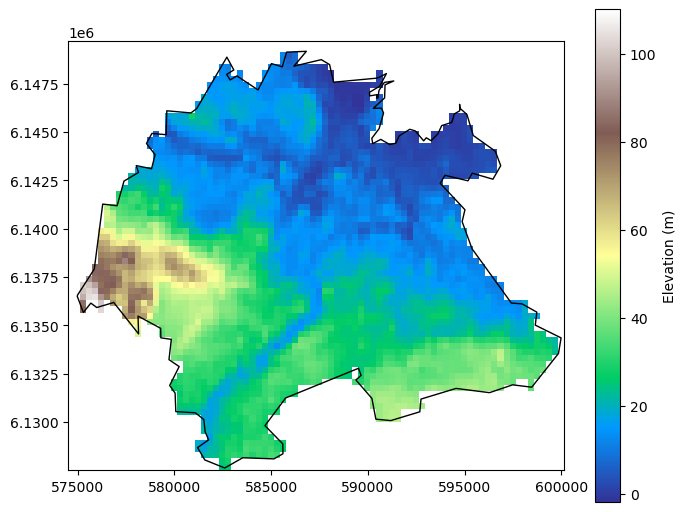

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

cmap = "terrain"
norm = mplc.Normalize(vmin=np.nanmin(band), vmax=np.nanmax(band))
fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Elevation (m)", shrink=0.8
)

show(band, ax=ax, transform=raster.transform, cmap=cmap, norm=norm)
region_boundary.boundary.plot(ax=ax, edgecolor="k", linewidth=1)

output_path = os.path.join(maps_dir, f"{filename.rsplit('.', 1)[0]}.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

In [14]:
def plot_elevations(above_below, height, band, ax):
    if above_below == "below":
        # Create the mask where values higher than height are masked (i.e., set to True)
        mask = band > height  # | (band == dem.meta['nodata'])
    if above_below == "above":
        # Create the mask where values lower than height are masked (i.e., set to True)
        mask = band < height  # | (band == dem.meta['nodata'])
    # Create the masked array
    masked_band = np.ma.masked_array(band, mask=mask)

    norm = mplc.Normalize(vmin=np.nanmin(band), vmax=np.nanmax(band))

    cmap = "terrain"
    show(masked_band, ax=ax, transform=raster.transform, cmap=cmap, norm=norm)
    ax.set_title(f"only heights {above_below}: {height}")

    # Add colorbar
    # fig.colorbar(im, ax=ax, orientation='vertical', label='Elevation (m)')
    fig.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax,
        label="Elevation (m)",
        shrink=0.8,
    )

<Axes: title={'center': 'only heights above: 120'}>

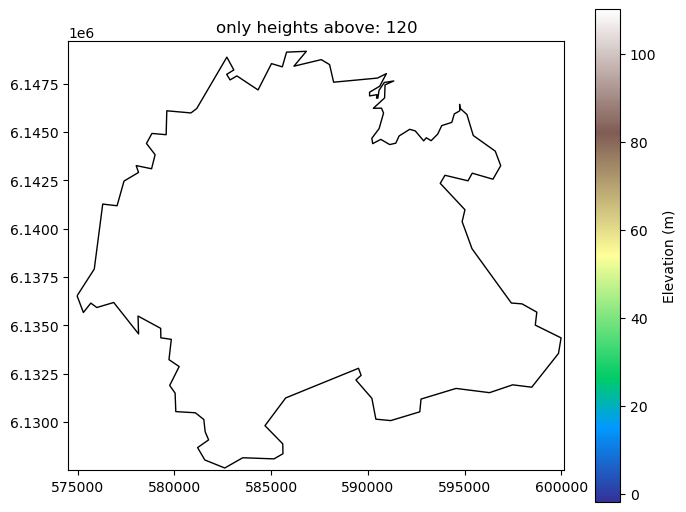

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_elevations("above", 120, band, ax)
region_boundary.boundary.plot(ax=ax, edgecolor="k", linewidth=1)

In [16]:
raster.close()

# Slope

CRS: EPSG:32632
bands (number of layers): 1
band shape: (71, 82)
number of Pixels: 5822
Pixel size (resolution): (312.7287832296421, 312.7287832296421)
the minimum raster value is:  0
the maximum raster value is:  2
nodata value:  -9999.0


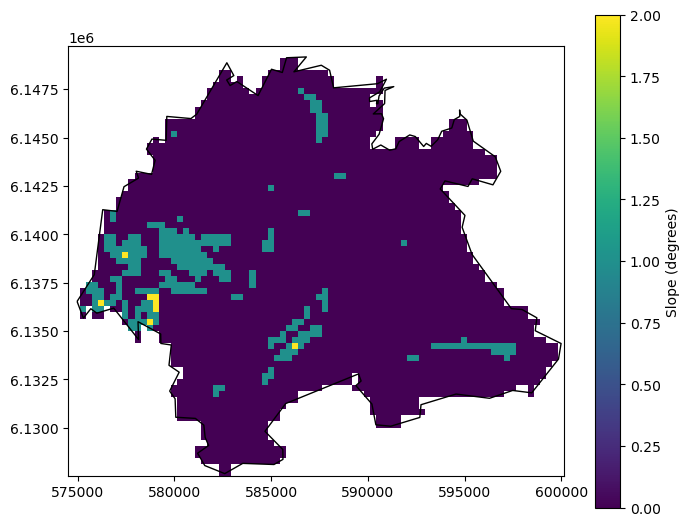

In [17]:
filename = f"slope_{region_name}_{local_crs_tag}.tif"
raster = rasterio.open(os.path.join(data_path2, filename))

band = raster.read(1, masked=True)  # masked=True is masking no data values
meta = raster.meta
print(f"CRS: {raster.crs}")
print(f"bands (number of layers): {raster.count}")

print(f"band shape: {band.shape}")
print(f"number of Pixels: {(band.shape[0] * band.shape[1])}")

print(f"Pixel size (resolution): {raster.res}")  # (x_resolution, y_resolution)

print("the minimum raster value is: ", band.min())
print("the maximum raster value is: ", band.max())
print("nodata value: ", raster.meta["nodata"])

fig, ax = plt.subplots(figsize=(8, 8))

cmap = "viridis"
norm = mplc.Normalize(vmin=np.nanmin(band), vmax=np.nanmax(band))
fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Slope (degrees)", shrink=0.8
)

show(band, ax=ax, transform=raster.transform, cmap=cmap, norm=norm)
region_boundary.boundary.plot(ax=ax, edgecolor="k", linewidth=1)

output_path = os.path.join(maps_dir, f"{filename.rsplit('.', 1)[0]}.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

raster.close()

# Aspect

CRS: EPSG:32632
bands (number of layers): 1
band shape: (71, 82)
number of Pixels: 5822
Pixel size (resolution): (312.7287832296421, 312.7287832296421)
the minimum raster value is:  0
the maximum raster value is:  359
nodata value:  -9999.0


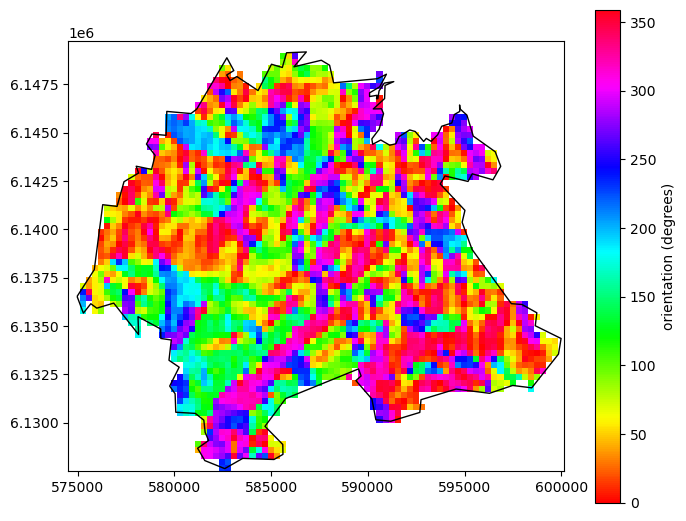

In [18]:
filename = f"aspect_{region_name}_{local_crs_tag}.tif"
raster = rasterio.open(os.path.join(data_path2, filename))

band = raster.read(1, masked=True)  # masked=True is masking no data values
meta = raster.meta
print(f"CRS: {raster.crs}")
print(f"bands (number of layers): {raster.count}")

print(f"band shape: {band.shape}")
print(f"number of Pixels: {(band.shape[0] * band.shape[1])}")

print(f"Pixel size (resolution): {raster.res}")  # (x_resolution, y_resolution)

print("the minimum raster value is: ", band.min())
print("the maximum raster value is: ", band.max())
print("nodata value: ", raster.meta["nodata"])

fig, ax = plt.subplots(figsize=(8, 8))

cmap = "hsv"
norm = mplc.Normalize(vmin=np.nanmin(band), vmax=np.nanmax(band))
fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    label="orientation (degrees)",
    shrink=0.8,
)

show(band, ax=ax, transform=raster.transform, cmap=cmap, norm=norm)
region_boundary.boundary.plot(ax=ax, edgecolor="k", linewidth=1)

output_path = os.path.join(maps_dir, f"{filename.rsplit('.', 1)[0]}.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

raster.close()

# Solar

CRS: EPSG:32632
bands (number of layers): 1
band shape: (36, 42)
number of Pixels: 1512
Pixel size (resolution): (625.5392741928946, 625.5392741928946)
the minimum raster value is:  1028.544
the maximum raster value is:  1054.112
nodata value:  1.1754943508222875e-38


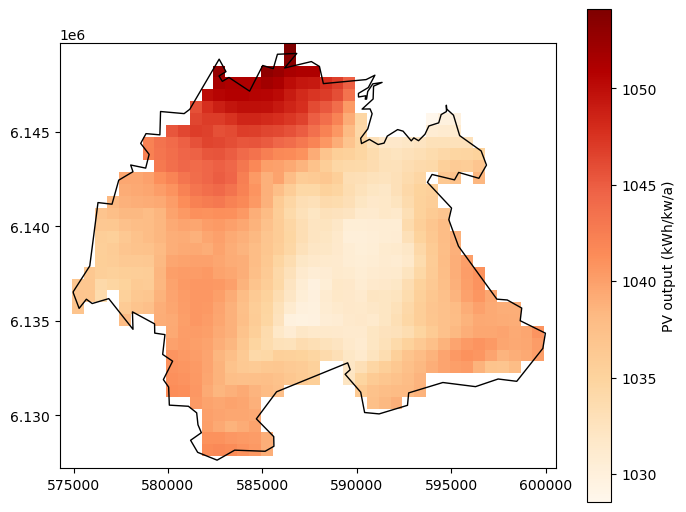

In [19]:
filename = f"solar_{region_name}_{local_crs_tag}.tif"
raster = rasterio.open(os.path.join(data_path, filename))

band = raster.read(1, masked=True)  # masked=True is masking no data values
meta = raster.meta
print(f"CRS: {raster.crs}")
print(f"bands (number of layers): {raster.count}")

print(f"band shape: {band.shape}")
print(f"number of Pixels: {(band.shape[0] * band.shape[1])}")

print(f"Pixel size (resolution): {raster.res}")  # (x_resolution, y_resolution)

print("the minimum raster value is: ", band.min())
print("the maximum raster value is: ", band.max())
print("nodata value: ", raster.meta["nodata"])

fig, ax = plt.subplots(figsize=(8, 8))

cmap = "OrRd"
norm = mplc.Normalize(vmin=np.nanmin(band), vmax=np.nanmax(band))
fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    label="PV output (kWh/kw/a)",
    shrink=0.8,
)

show(band, ax=ax, transform=raster.transform, cmap=cmap, norm=norm)
region_boundary.boundary.plot(ax=ax, edgecolor="k", linewidth=1)

output_path = os.path.join(maps_dir, f"{filename.rsplit('.', 1)[0]}.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

raster.close()

# Wind

CRS: EPSG:32632
bands (number of layers): 1
band shape: (118, 136)
number of Pixels: 16048
Pixel size (resolution): (187.72910864462273, 187.72910864462273)
the minimum raster value is:  7.303009
the maximum raster value is:  8.425214
nodata value:  nan


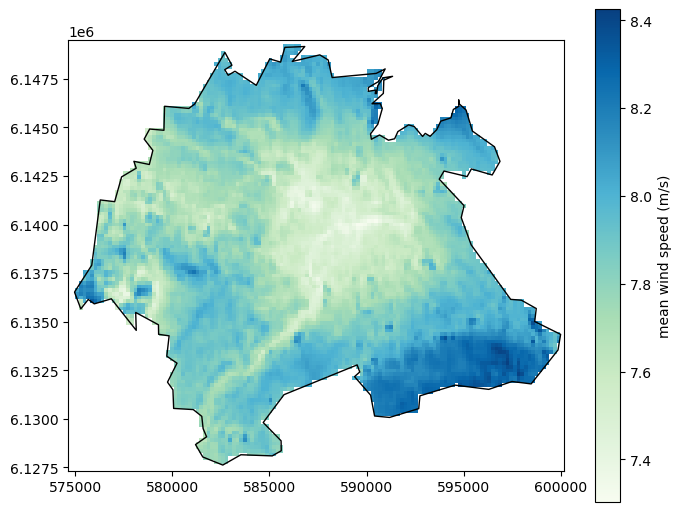

In [20]:
filename = f"wind_{region_name}_{local_crs_tag}.tif"
raster = rasterio.open(os.path.join(data_path, filename))

band = raster.read(1, masked=True)  # masked=True is masking no data values
meta = raster.meta
print(f"CRS: {raster.crs}")
print(f"bands (number of layers): {raster.count}")

print(f"band shape: {band.shape}")
print(f"number of Pixels: {(band.shape[0] * band.shape[1])}")

print(f"Pixel size (resolution): {raster.res}")  # (x_resolution, y_resolution)

print("the minimum raster value is: ", band.min())
print("the maximum raster value is: ", band.max())
print("nodata value: ", raster.meta["nodata"])

fig, ax = plt.subplots(figsize=(8, 8))

cmap = "GnBu"
norm = mplc.Normalize(vmin=np.nanmin(band), vmax=np.nanmax(band))
fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    label="mean wind speed (m/s)",
    shrink=0.8,
)

show(band, ax=ax, transform=raster.transform, cmap=cmap, norm=norm)
region_boundary.boundary.plot(ax=ax, edgecolor="k", linewidth=1)

output_path = os.path.join(maps_dir, f"{filename.rsplit('.', 1)[0]}.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

raster.close()

# available land

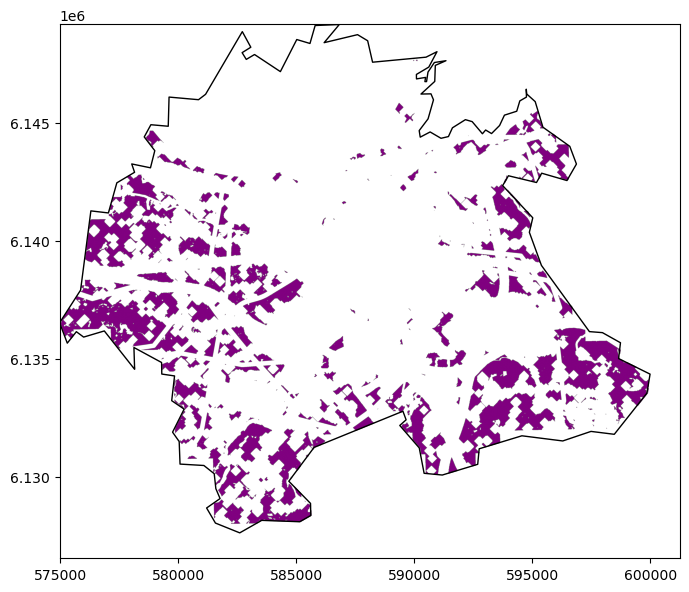

In [21]:
scenario = "test1"
technology = "solar"

filename = f"{region_name}_{technology}_{scenario}_available_land.tif"
raster = rasterio.open(os.path.join(data_path, "available_land", filename))

band = raster.read(1, masked=True)  # masked=True is masking no data values


fig, ax = plt.subplots(figsize=(8, 8))

# Create custom colormap: transparent for 0 (nodata), purple for 1 (available land)
colors = ["none", "purple"]
cmap = ListedColormap(colors)

show(band, ax=ax, transform=raster.transform, cmap=cmap, vmin=0, vmax=1)
region_boundary.boundary.plot(ax=ax, edgecolor="k", linewidth=1)


raster.close()